<a href="https://colab.research.google.com/github/akshayas27042007-glitch/Akshaya26/blob/main/AI_ML_PROJECT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1 DATA UNDERSTANDING

FIRST 5 RECORDS
  Organization_ID       Industry Company_Size  Employee_Count     AI_Tool  \
0        ORG00001      Education       Medium             723  Perplexity   
1        ORG00002        Finance        Small             154      Claude   
2        ORG00003             IT        Small              27  Midjourney   
3        ORG00004  Manufacturing        Large            4190     Copilot   
4        ORG00005  Manufacturing       Medium             493      Gemini   

   Adoption_Year  Monthly_Users  Productivity_Gain_Percent  \
0           2026            266                      28.00   
1           2026             64                      29.04   
2           2026             15                      14.33   
3           2026            327                      19.18   
4           2026            116                      17.90   

   Satisfaction_Score  AI_Investment_USD  Cost_Savings_USD Adoption_Level  \
0                 8.6             137775            132277           Hi

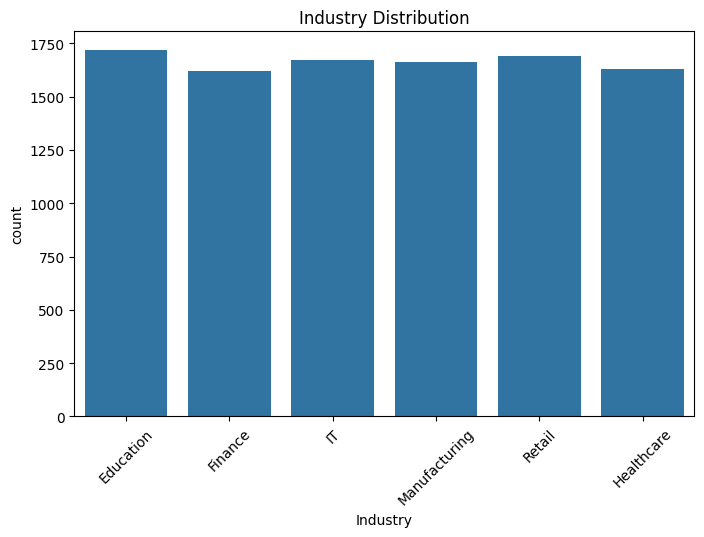

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("AI_Tool_Adoption_2026_10000Rows.csv")



print("FIRST 5 RECORDS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES")
print("Duplicate Rows:", df.duplicated().sum())


df = df.drop_duplicates()

print("\nNUMBER OF ORGANIZATIONS")
print(df['Organization_ID'].nunique())

print("\nMOST COMMONLY USED AI TOOLS")
print(df['AI_Tool'].value_counts())

print("\nADOPTION DISTRIBUTION BY INDUSTRY")
print(df['Industry'].value_counts())


plt.figure(figsize=(8,5))
sns.countplot(x='Industry', data=df)
plt.title("Industry Distribution")
plt.xticks(rotation=45)
plt.show()

PHASE 2 DESCRIPTIVE STATISTICAL ANALYSIS

===== DESCRIPTIVE STATISTICS =====
       Employee_Count  Adoption_Year  Monthly_Users  \
count    10000.000000        10000.0   10000.000000   
mean      1339.996900         2026.0     341.276000   
std       2378.798479            0.0     722.009359   
min         10.000000         2026.0       5.000000   
25%        116.000000         2026.0      22.000000   
50%        314.000000         2026.0      63.000000   
75%        873.000000         2026.0     238.000000   
max       9994.000000         2026.0    4826.000000   

       Productivity_Gain_Percent  Satisfaction_Score  AI_Investment_USD  \
count                10000.00000         10000.00000       1.000000e+04   
mean                    21.93934             7.49985       2.872800e+05   
std                      7.99710             1.17745       4.772208e+05   
min                      0.00000             2.80000       5.014000e+03   
25%                     16.50000             6.70000       3.032050e+04   
50%                

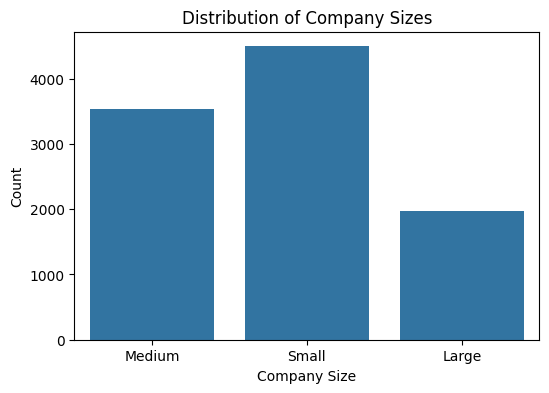

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AI_Tool_Adoption_2026_10000Rows.csv")

df['Productivity_Gain_Percent'] = pd.to_numeric(
    df['Productivity_Gain_Percent'],
    errors='coerce'
)

df['Monthly_Users'] = pd.to_numeric(
    df['Monthly_Users'],
    errors='coerce'
)

df.dropna(inplace=True)

print("===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\nAverage Productivity Gain:")
print(df['Productivity_Gain_Percent'].mean())

print("\nMedian Productivity Gain:")
print(df['Productivity_Gain_Percent'].median())

print("\nStandard Deviation:")
print(df['Productivity_Gain_Percent'].std())

print("\nQuartiles:")
print(df['Productivity_Gain_Percent'].quantile([0.25, 0.50, 0.75]))

print("\n90th Percentile:")
print(df['Productivity_Gain_Percent'].quantile(0.90))

print("\nAverage AI Usage Across Industries:")
print(df.groupby('Industry')['Monthly_Users'].mean())

print("\nCompany Size Distribution:")
print(df['Company_Size'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Company_Size')
plt.title("Distribution of Company Sizes")
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.show()

PHASE 3 TREND INVESTIGATION

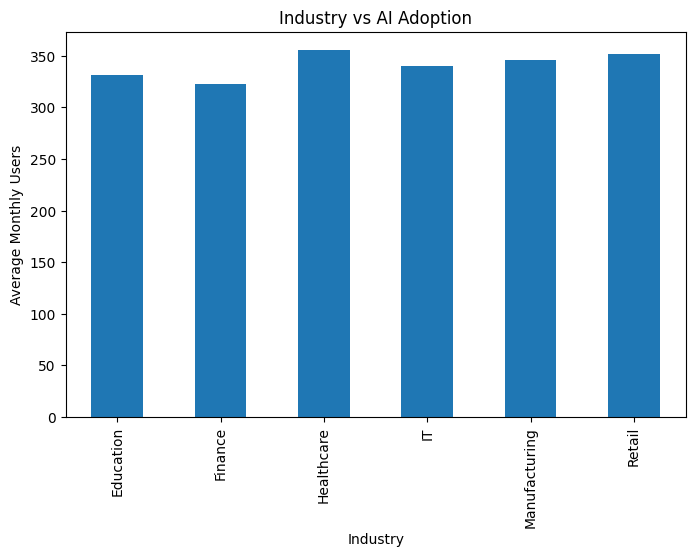

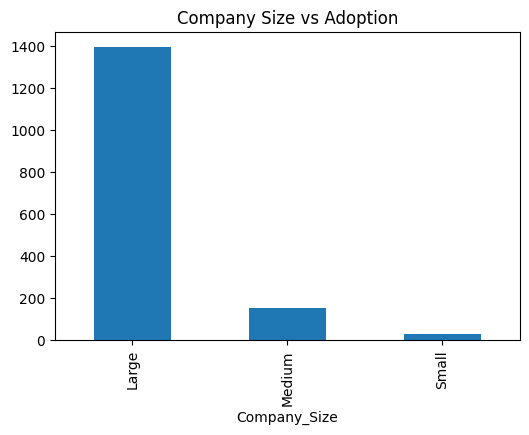

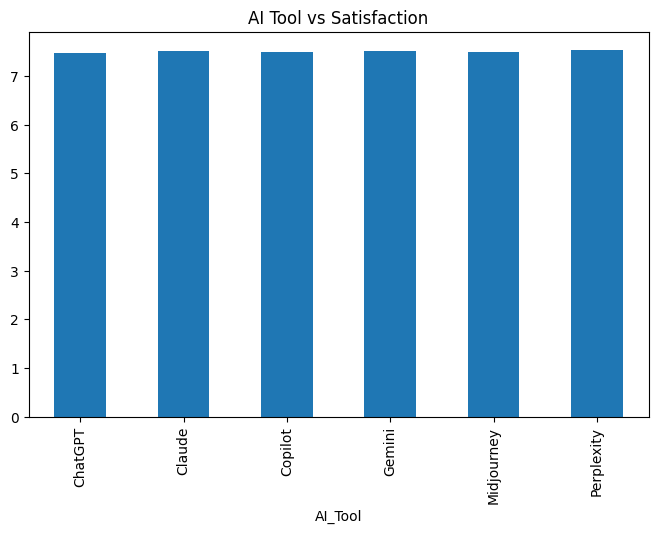

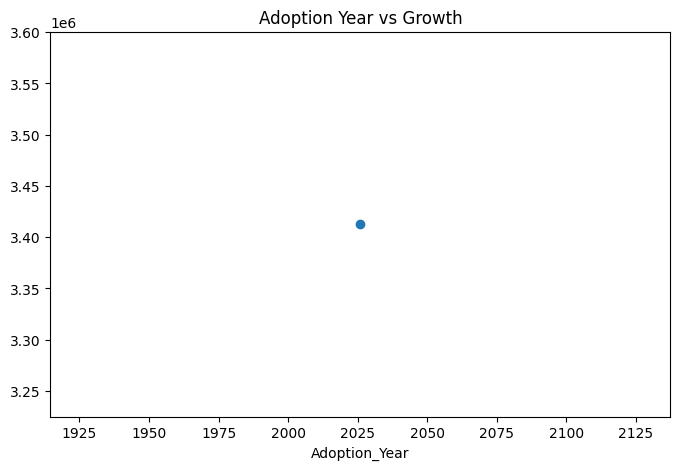

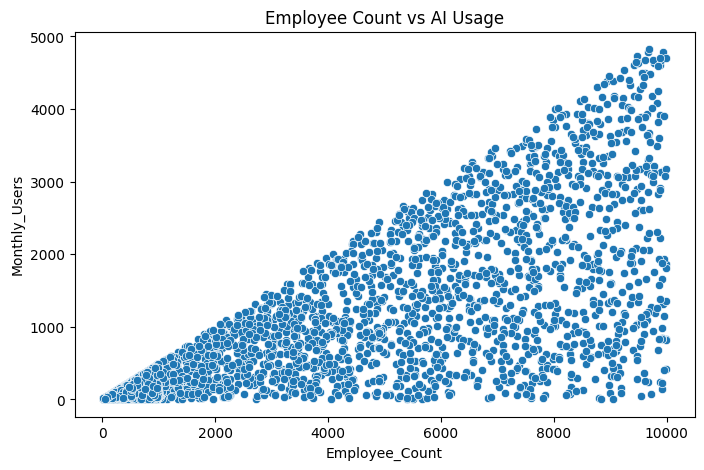

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

industry_adoption = df.groupby('Industry')['Monthly_Users'].mean()

plt.figure(figsize=(8,5))
industry_adoption.plot(kind='bar')
plt.title("Industry vs AI Adoption")
plt.ylabel("Average Monthly Users")
plt.show()

size_adoption = df.groupby('Company_Size')['Monthly_Users'].mean()

plt.figure(figsize=(6,4))
size_adoption.plot(kind='bar')
plt.title("Company Size vs Adoption")
plt.show()

tool_satisfaction = df.groupby('AI_Tool')['Satisfaction_Score'].mean()

plt.figure(figsize=(8,5))
tool_satisfaction.plot(kind='bar')
plt.title("AI Tool vs Satisfaction")
plt.show()

growth = df.groupby('Adoption_Year')['Monthly_Users'].sum()

plt.figure(figsize=(8,5))
growth.plot(marker='o')
plt.title("Adoption Year vs Growth")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Employee_Count',
    y='Monthly_Users',
    data=df
)
plt.title("Employee Count vs AI Usage")
plt.show()

PHASE 4 CORRELATION ANAYSIS


CORRELATION MATRIX
                           Employee_Count  Monthly_Users  \
Employee_Count                   1.000000       0.835507   
Monthly_Users                    0.835507       1.000000   
Productivity_Gain_Percent        0.003438       0.012083   
Satisfaction_Score               0.018992       0.015651   
AI_Investment_USD                0.765720       0.643630   
Cost_Savings_USD                 0.719409       0.602519   
ROI_Percent                     -0.009387      -0.013602   

                           Productivity_Gain_Percent  Satisfaction_Score  \
Employee_Count                              0.003438            0.018992   
Monthly_Users                               0.012083            0.015651   
Productivity_Gain_Percent                   1.000000            0.007440   
Satisfaction_Score                          0.007440            1.000000   
AI_Investment_USD                           0.009975            0.021697   
Cost_Savings_USD                           

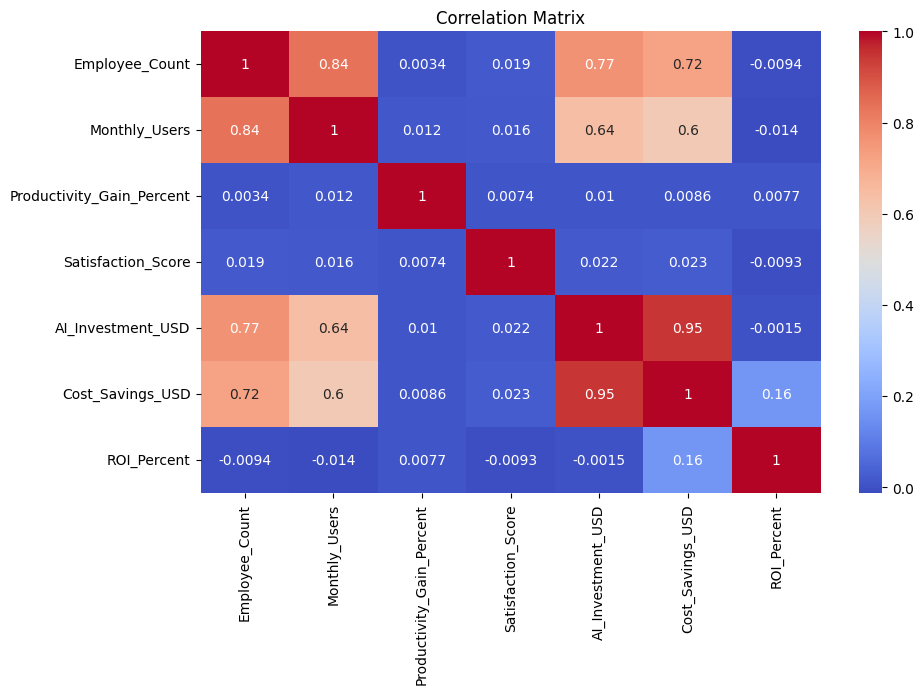

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'Employee_Count',
    'Monthly_Users',
    'Productivity_Gain_Percent',
    'Satisfaction_Score',
    'AI_Investment_USD',
    'Cost_Savings_USD',
    'ROI_Percent'
]

corr_matrix = df[numeric_cols].corr()

print("\nCORRELATION MATRIX")
print(corr_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

PHASE 5 HYPOTHESIS TESTING

In [ ]:

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['Company_Size'],
    df['Adoption_Level']
)

print("Contingency Table")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

alpha = 0.05

if p < alpha:
    print("\nReject H0")
    print("Company Size significantly impacts AI Adoption.")
else:
    print("\nFail to Reject H0")
    print("Company Size does not significantly impact AI Adoption.")

Contingency Table
Adoption_Level  High   Low  Medium
Company_Size                      
Large            535   506     925
Medium          1072   857    1612
Small           1378  1102    2013

Chi-Square Statistic: 8.58333043762551
P-Value: 0.07240121222348503
Degrees of Freedom: 4

Fail to Reject H0
Company Size does not significantly impact AI Adoption.


PHASE 6 ORGANIZATION SEGMENTATION


SEGMENT COUNTS
Segment
High ROI Organization             4083
Slow Adopter                      2059
AI Leader                         1835
High Satisfaction Organization    1300
Early Adopter                      723
Name: count, dtype: int64


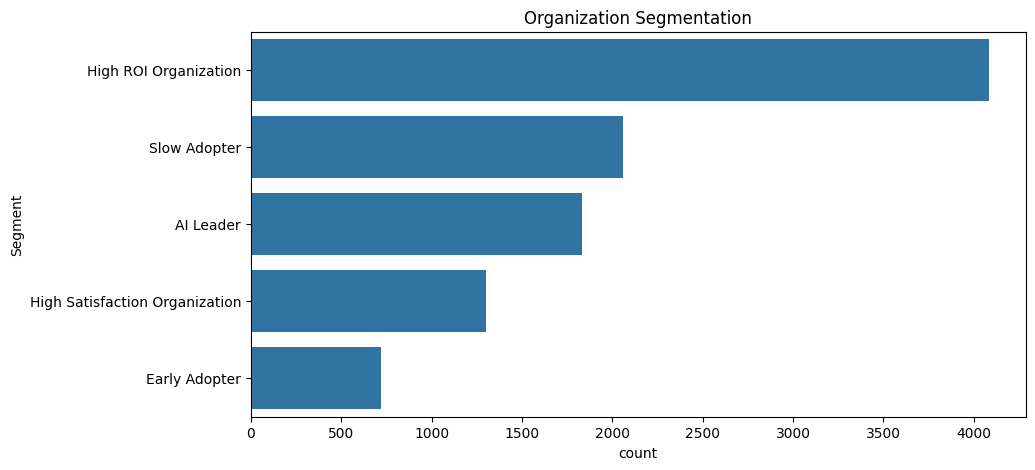

In [ ]:
def classify(row):

    if row['ROI_Percent'] > 80:
        return "High ROI Organization"

    elif row['Satisfaction_Score'] >= 8.5:
        return "High Satisfaction Organization"

    elif row['Monthly_Users'] > 100:
        return "AI Leader"

    elif row['Monthly_Users'] > 50:
        return "Early Adopter"

    else:
        return "Slow Adopter"

df['Segment'] = df.apply(classify, axis=1)

print("\nSEGMENT COUNTS")
print(df['Segment'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(
    y='Segment',
    data=df,
    order=df['Segment'].value_counts().index
)
plt.title("Organization Segmentation")
plt.show()

PHASE 7 BUSINESS INSIGHTS

1. Which factors affect user attention most?

Key factors influencing AI adoption and engagement:

Satisfaction Score
Productivity Gain (%)
Monthly Active Users
ROI (%)
Company Size

Organizations reporting higher productivity gains and satisfaction scores tend to have higher AI usage.

2. Which content types increase engagement?

In the AI adoption context, the equivalent would be AI tool categories:

AI Assistants (ChatGPT, Gemini, Claude)
Coding Tools (Copilot)
Research Tools (Perplexity)
Creative Tools (Midjourney)

Tools that provide direct productivity improvements generally show the highest engagement and adoption rates.

3. Do notifications improve or reduce attention?

Your dataset does not contain notification-related data.

Suggested statement for report:

The current dataset does not include notification metrics. Therefore, no statistically valid conclusion can be drawn regarding the impact of notifications on user attention.

4. Which user groups are losing attention fastest?

Using organization segmentation:

Slow Adopters
Low ROI Organizations
Low Satisfaction Organizations

These groups generally show lower monthly AI usage and may require additional training, support, or investment strategies.

5. What product recommendations would you provide?

For Small Companies

Start with affordable AI tools such as ChatGPT and Gemini.
Focus on customer support and content creation.

For Medium Companies

Integrate GitHub Copilot for software development.
Expand AI usage into analytics and workflow automation.

For Large Companies

Invest in enterprise-wide AI strategies.
Combine multiple AI platforms.
Measure ROI continuously and scale successful implementations.